# SolarScan — 04c · Pousser la performance (v3)

Le 04b a donné **macro-F1 = 0.653**. On essaie de faire mieux avec 4 leviers, chacun ciblant une faiblesse observée :

1. **EfficientNet-B0** au lieu de ResNet-18 — architecture plus moderne et efficace.
2. **WeightedRandomSampler** — au lieu de pondérer la perte, on **sur-échantillonne** les classes rares : le modèle les voit plus souvent (mieux pour Soiling, Hot-Spot...).
3. **25 epochs + cosine** — au 04b la validation montait encore, on laisse plus de temps.
4. **Test-Time Augmentation (TTA)** — à l'évaluation, on moyenne les prédictions sur l'image + ses miroirs. Gain gratuit, sans réentraîner.

> ⚡ Colab GPU, Run all. ~30-40 min.

## 0. Setup

In [1]:
%pip install -q torch torchvision scikit-learn pandas pillow matplotlib

In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image

from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device :', device)

Device : cuda


In [3]:
DATA_DIR = Path('data') if Path('data').exists() else Path('../data')
SPLITS = Path('splits') if Path('splits').exists() else Path('../splits')

if not (DATA_DIR / 'module_metadata.json').exists():
    import urllib.request, zipfile, shutil
    print('Telechargement du dataset...')
    url = 'https://github.com/RaptorMaps/InfraredSolarModules/raw/master/2020-02-14_InfraredSolarModules.zip'
    urllib.request.urlretrieve(url, 'solar.zip')
    with zipfile.ZipFile('solar.zip') as z:
        z.extractall('tmp')
    shutil.move('tmp/InfraredSolarModules', 'data')
    DATA_DIR = Path('data')

if not (SPLITS / 'train.csv').exists():
    from sklearn.model_selection import train_test_split
    with open(DATA_DIR / 'module_metadata.json', encoding='utf-8') as f:
        meta = json.load(f)
    data = pd.DataFrame([{'filepath': v['image_filepath'], 'classe': v['anomaly_class']}
                         for v in meta.values()])
    tr, tmp = train_test_split(data, test_size=0.30, stratify=data['classe'], random_state=42)
    va, te = train_test_split(tmp, test_size=0.50, stratify=tmp['classe'], random_state=42)
    SPLITS = Path('splits'); SPLITS.mkdir(exist_ok=True)
    tr.to_csv(SPLITS / 'train.csv', index=False)
    va.to_csv(SPLITS / 'val.csv', index=False)
    te.to_csv(SPLITS / 'test.csv', index=False)

print('OK :', DATA_DIR.resolve())

Telechargement du dataset...
OK : /content/data


## 1. Dataset, augmentation & sur-échantillonnage des classes rares

Le **WeightedRandomSampler** donne à chaque image une probabilité de tirage **inversement proportionnelle à la taille de sa classe** → les batches deviennent quasi équilibrés. Comme c'est lui qui gère le déséquilibre, on utilise une perte simple (sans poids).

In [4]:
CLASSES = sorted(pd.read_csv(SPLITS / 'train.csv')['classe'].unique())
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}

MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
train_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
eval_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

class SolarDataset(Dataset):
    def __init__(self, csv_path, transform):
        self.df = pd.read_csv(csv_path)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(DATA_DIR / row['filepath'])
        return self.transform(img), CLASS_TO_IDX[row['classe']]

# Sur-echantillonnage : poids = 1 / taille_de_la_classe
train_labels = pd.read_csv(SPLITS / 'train.csv')['classe']
class_count = train_labels.value_counts()
sample_w = train_labels.map(lambda c: 1.0 / class_count[c]).values
sampler = WeightedRandomSampler(torch.DoubleTensor(sample_w), num_samples=len(sample_w), replacement=True)

train_dl = DataLoader(SolarDataset(SPLITS / 'train.csv', train_tf), batch_size=64, sampler=sampler, num_workers=2)
val_dl = DataLoader(SolarDataset(SPLITS / 'val.csv', eval_tf), batch_size=64, shuffle=False, num_workers=2)
test_dl = DataLoader(SolarDataset(SPLITS / 'test.csv', eval_tf), batch_size=64, shuffle=False, num_workers=2)
n_train = len(train_dl.dataset)
print('train/val/test :', n_train, len(val_dl.dataset), len(test_dl.dataset))

train/val/test : 14000 3000 3000


## 2. Modèle — EfficientNet-B0 pré-entraîné

In [5]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
in_feats = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_feats, len(CLASSES))
model = model.to(device)
print('Tete :', model.classifier[1])

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 85.9MB/s]


Tete : Linear(in_features=1280, out_features=12, bias=True)


## 3. Perte (simple + label smoothing)

Le sampler équilibre déjà les classes → perte standard, juste avec un peu de label smoothing.

In [6]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

## 4. Fonctions train / éval / TTA

In [7]:
def macro_f1(model, loader):
    model.eval()
    preds, gts = [], []
    with torch.no_grad():
        for x, y in loader:
            preds += model(x.to(device)).argmax(1).cpu().tolist()
            gts += y.tolist()
    return f1_score(gts, preds, average='macro'), preds, gts

def tta_predict(model, loader):
    """Moyenne les logits sur image + miroir horizontal + miroir vertical."""
    model.eval()
    preds, gts = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x) + model(torch.flip(x, dims=[3])) + model(torch.flip(x, dims=[2]))
            preds += logits.argmax(1).cpu().tolist()
            gts += y.tolist()
    return preds, gts

def train(model, criterion, optimizer, scheduler, epochs, patience=6, tag='phase'):
    best_f1, best_state, wait = 0.0, None, 0
    for epoch in range(epochs):
        model.train()
        running = 0.0
        for x, y in train_dl:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            running += loss.item() * x.size(0)
        if scheduler is not None:
            scheduler.step()
        val_f1, _, _ = macro_f1(model, val_dl)
        print(f'[{tag}] epoch {epoch+1}/{epochs} - loss {running/n_train:.3f} - val macro-F1 {val_f1:.3f}')
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print('  -> early stopping')
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    return best_f1

## 5. Phase 1 — tête seule (backbone gelé)

In [8]:
for p in model.parameters():
    p.requires_grad = False
for p in model.classifier.parameters():
    p.requires_grad = True

opt1 = torch.optim.AdamW(model.classifier.parameters(), lr=1e-3, weight_decay=1e-4)
train(model, criterion, opt1, None, epochs=4, patience=4, tag='tete')

[tete] epoch 1/4 - loss 2.182 - val macro-F1 0.224
[tete] epoch 2/4 - loss 2.021 - val macro-F1 0.215
[tete] epoch 3/4 - loss 1.981 - val macro-F1 0.241
[tete] epoch 4/4 - loss 1.959 - val macro-F1 0.251


0.25118381752254504

## 6. Phase 2 — fine-tuning complet (25 epochs, cosine)

In [9]:
for p in model.parameters():
    p.requires_grad = True

EPOCHS2 = 25
opt2 = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=EPOCHS2)
best = train(model, criterion, opt2, sched, epochs=EPOCHS2, patience=6, tag='fine-tune')

torch.save(model.state_dict(), 'best_model_v3.pt')
print('Meilleur val macro-F1 :', round(best, 3))

[fine-tune] epoch 1/25 - loss 1.667 - val macro-F1 0.432
[fine-tune] epoch 2/25 - loss 1.408 - val macro-F1 0.497
[fine-tune] epoch 3/25 - loss 1.276 - val macro-F1 0.541
[fine-tune] epoch 4/25 - loss 1.196 - val macro-F1 0.599
[fine-tune] epoch 5/25 - loss 1.120 - val macro-F1 0.583
[fine-tune] epoch 6/25 - loss 1.057 - val macro-F1 0.609
[fine-tune] epoch 7/25 - loss 1.028 - val macro-F1 0.610
[fine-tune] epoch 8/25 - loss 0.984 - val macro-F1 0.624
[fine-tune] epoch 9/25 - loss 0.949 - val macro-F1 0.643
[fine-tune] epoch 10/25 - loss 0.936 - val macro-F1 0.646
[fine-tune] epoch 11/25 - loss 0.906 - val macro-F1 0.642
[fine-tune] epoch 12/25 - loss 0.886 - val macro-F1 0.654
[fine-tune] epoch 13/25 - loss 0.862 - val macro-F1 0.642
[fine-tune] epoch 14/25 - loss 0.852 - val macro-F1 0.657
[fine-tune] epoch 15/25 - loss 0.841 - val macro-F1 0.665
[fine-tune] epoch 16/25 - loss 0.832 - val macro-F1 0.675
[fine-tune] epoch 17/25 - loss 0.831 - val macro-F1 0.672
[fine-tune] epoch 18/25

## 7. Évaluation — sans puis avec TTA

In [10]:
# Sans TTA
f1_plain, preds, gts = macro_f1(model, test_dl)
print('SANS TTA  -> accuracy', round(accuracy_score(gts, preds), 3), '| macro-F1', round(f1_plain, 3))

# Avec TTA
preds_tta, gts_tta = tta_predict(model, test_dl)
print('AVEC TTA  -> accuracy', round(accuracy_score(gts_tta, preds_tta), 3), '| macro-F1', round(f1_score(gts_tta, preds_tta, average='macro'), 3))
print()
print(classification_report(gts_tta, preds_tta, target_names=CLASSES))

SANS TTA  -> accuracy 0.773 | macro-F1 0.644
AVEC TTA  -> accuracy 0.786 | macro-F1 0.66

                precision    recall  f1-score   support

          Cell       0.69      0.72      0.71       281
    Cell-Multi       0.57      0.54      0.56       193
      Cracking       0.72      0.77      0.74       141
         Diode       0.95      0.97      0.96       225
   Diode-Multi       0.86      0.92      0.89        26
      Hot-Spot       0.47      0.49      0.48        37
Hot-Spot-Multi       0.40      0.51      0.45        37
    No-Anomaly       0.96      0.84      0.89      1500
Offline-Module       0.47      0.75      0.58       124
     Shadowing       0.58      0.83      0.68       159
       Soiling       0.42      0.26      0.32        31
    Vegetation       0.63      0.70      0.67       246

      accuracy                           0.79      3000
     macro avg       0.64      0.69      0.66      3000
  weighted avg       0.81      0.79      0.79      3000



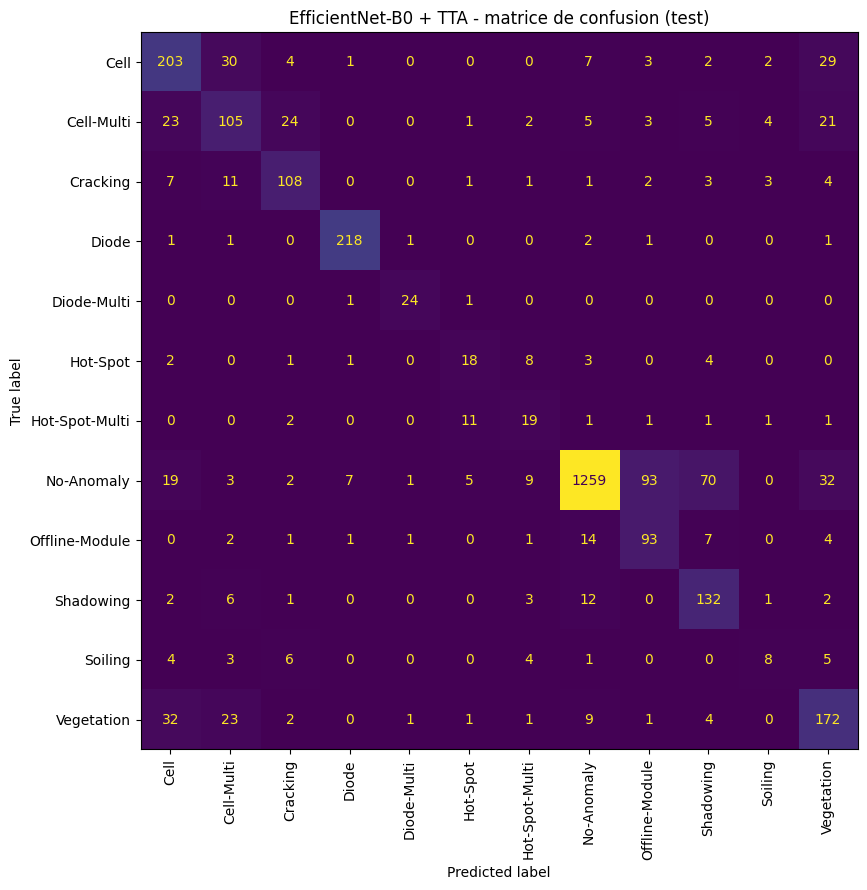

In [11]:
cm = confusion_matrix(gts_tta, preds_tta)
fig, ax = plt.subplots(figsize=(9, 9))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(
    ax=ax, xticks_rotation=90, colorbar=False)
plt.title('EfficientNet-B0 + TTA - matrice de confusion (test)')
plt.tight_layout()
plt.show()

## 8. Bilan

| Modèle | Macro-F1 (test) |
|---|---|
| ResNet-18 (04) | 0.487 |
| ResNet-18 amélioré (04b) | 0.653 |
| **EfficientNet-B0 + TTA (04c)** | **_ce notebook_** |

Compare le rapport par classe au 04b : les **classes rares** (Soiling, Hot-Spot) ont-elles progressé grâce au sur-échantillonnage ?

On garde la **meilleure** des trois versions comme modèle final → README + CV.